In [1]:
import json
def load_json(p: str):
    with open(p) as f:
        return json.load(f)

In [2]:
import numpy as np


def collaboration_rate(domain_values: np.ndarray):
    return (domain_values[..., 1] / (domain_values[..., 0] * 1.0))

def own_coin_rate(domain_values: np.ndarray):
    return np.divide(domain_values[..., 2], domain_values[..., 1], out=np.zeros_like(domain_values[..., 2]), where=domain_values[..., 1] !=0 )

def sustainability(domain_values: np.ndarray):
    return domain_values[..., 3] / (domain_values[..., 0] * 1.0)

In [3]:
nr_epochs = 300

In [5]:
from pathlib import Path

directory = Path('./output/unstable_communication_drive')
paths = np.array([list(d.rglob('*.json')) for d in directory.iterdir() if not d.is_file()])

In [6]:
data = np.vectorize(load_json)(paths)

In [7]:
def map_domain_values_to_metric_fun(metric):
    def map_to_metric(data: list[dict]):
        domain_values = np.array([d['domain_values'][:nr_epochs] for d in data])
        return metric(domain_values)

    return map_to_metric

In [8]:
domain_values = np.array([d['domain_values'][:nr_epochs] for d in data[0, :]])

In [11]:
metrics = np.zeros(shape=(data.shape[0], data.shape[1], nr_epochs))
metrics[0] = map_domain_values_to_metric_fun(own_coin_rate)(data[0, :])
#metrics[1] = map_domain_values_to_metric_fun(own_coin_rate)(data[1, :])
#metrics[-1] = map_domain_values_to_metric_fun(collaboration_rate)(data[-1, :])

In [12]:
metrics.shape

(1, 8, 300)

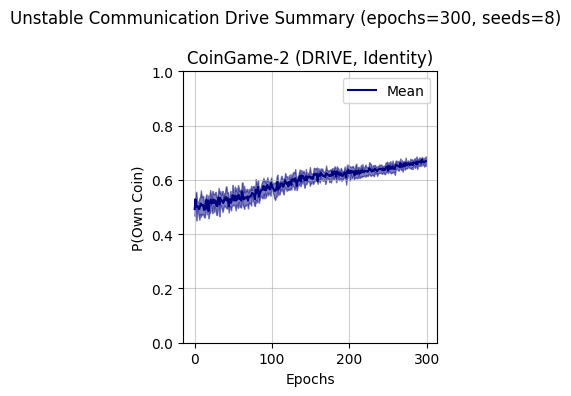

In [13]:
from matplotlib import pyplot as plt
import os
from datetime import datetime

fig, axs = plt.subplots(1, data.shape[0], figsize=(3.375 * data.shape[0], 4))
plt.suptitle(f'Unstable Communication Drive Summary (epochs={nr_epochs}, seeds={metrics.shape[1]})')

cmap = plt.get_cmap('jet')

axs = axs.flatten() if type(axs) is np.ndarray else [axs]

for ax, game_name, metric_name, ylim, metric_data in zip(axs, ["CoinGame-2", "CoinGame-4", "Matrix-IPD"], ["P(Own Coin)", "P(Own Coin)", "Cooperation Rate"], [(0, 1), (0, 1), None, (0, 1)], metrics,  strict=False):

    means = metric_data.mean(axis=0)
    stds = metric_data.std(axis=0)
    ax.plot(
        list(range(nr_epochs)),
        means,
        label='Mean',
        color=cmap(0)
    )

    ax.fill_between(list(range(nr_epochs)), means - stds, means + stds, color=cmap(0), alpha=0.5)

    ax.set_title(f'{game_name} (DRIVE, Identity)')
    ax.set_ylim(ylim)
    ax.set_xlabel('Epochs')
    ax.set_ylabel(metric_name)
    ax.grid(alpha=0.6)
    ax.legend()
    fig.tight_layout()

    save_dir_name = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
    os.makedirs(f"plots/unstable_communication_drive/{save_dir_name}", exist_ok=True)
    fig.savefig(f'plots/unstable_communication_drive/{save_dir_name}/summary.png')
